# CNN 3D: Prior-Frame Waymo Maneuver Classification

This notebook extends the `CNN_2D.ipynb` workflow from one target image
to a short RGB clip. It keeps the exact train, validation, and test
assignments created by `CNN_2D_resplit.ipynb`.

The temporal design is intentionally prediction-oriented:

- Only frames with a numeric frame index **strictly before** the target
  frame are eligible.
- The target frame and every later frame are excluded.
- The source window contains at most the 20 most recent prior frames.
- A fixed 16-frame clip is sampled in chronological order because a
  standard 3D CNN requires a consistent input shape.
- When fewer than 16 prior frames exist, the clip is left-padded by
  repeating the earliest available prior frame.
- When no prior frame exists, black frames are used for padding. The
  target frame is never substituted.

The GIFs in this notebook are visualization artifacts only. The model
consumes the original ordered frame tensors, not encoded GIF files.

TensorFlow references:

- [Video classification with a 3D CNN](https://www.tensorflow.org/tutorials/video/video_classification)
- [`tf.keras.layers.Conv3D`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv3D)

## Why use prior-frame clips?

A single pre-maneuver image contains road geometry but little direct
evidence of vehicle motion. A 3D convolution slides across time,
height, and width, allowing the model to learn short-term changes in
lane position, heading, and intersection approach.

This notebook uses a custom Conv3D network rather than a pretrained
video model. The network is deliberately compact because the number of
labeled Waymo sequences is much smaller than a typical video dataset.

# Step 1: Import packages and set reproducible behavior

The random seeds make model initialization, batch shuffling, baseline
predictions, and hyperparameter trials repeatable when software and
hardware versions are unchanged.

In [1]:
import gc
import hashlib
import json
import math
import random
import re
import time
from pathlib import Path

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from IPython.display import Image as IPythonImage
from IPython.display import Markdown, display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
    print('TensorFlow deterministic operations enabled.')
except Exception as error:
    print(f'Deterministic operations were not enabled: {error}')

print(f'TensorFlow version: {tf.__version__}')
print(f'NumPy version: {np.__version__}')
print(f'Available GPUs: {tf.config.list_physical_devices("GPU")}')

TensorFlow deterministic operations enabled.
TensorFlow version: 2.21.0
NumPy version: 2.3.5
Available GPUs: []


# Step 2: Define paths and temporal clip settings

`CLIP_LENGTH` can be changed to any value from 12 through 20. The
default uses 16 frames sampled from the 20-frame source window.

The 3D inputs use a smaller spatial resolution than the 2D CNN because
every sample contains many RGB frames. Binary `.npy` clip caches are
used instead of enormous flattened CSV files.

In [2]:
# Use the project root whether the notebook starts from the project
# root or from inside the notebooks directory.
current_dir = Path.cwd()
PROJECT_ROOT = (
    current_dir.parent
    if current_dir.name == 'notebooks'
    else current_dir
)

CNN_2D_DATA_DIR = (
    PROJECT_ROOT
    / 'data'
    / 'processed'
    / 'waymo_e2e'
    / 'CNN_2D'
)
CNN_3D_DATA_DIR = (
    PROJECT_ROOT
    / 'data'
    / 'processed'
    / 'waymo_e2e'
    / 'CNN_3D'
)
CLIP_CACHE_DIR = CNN_3D_DATA_DIR / 'clip_cache'
GIF_OUTPUT_DIR = CNN_3D_DATA_DIR / 'example_gifs'

CNN_3D_DATA_DIR.mkdir(parents=True, exist_ok=True)
CLIP_CACHE_DIR.mkdir(parents=True, exist_ok=True)
GIF_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_NAMES = ['train', 'val', 'test']

DF_PATHS = {
    split_name: CNN_2D_DATA_DIR / f'df_{split_name}.csv'
    for split_name in SPLIT_NAMES
}
Y_PATHS = {
    split_name: CNN_2D_DATA_DIR / f'y_{split_name}.csv'
    for split_name in SPLIT_NAMES
}
CLIP_CACHE_PATHS = {
    split_name: CLIP_CACHE_DIR / f'X_{split_name}_clips.npy'
    for split_name in SPLIT_NAMES
}
CLIP_METADATA_PATHS = {
    split_name: (
        CLIP_CACHE_DIR / f'clip_metadata_{split_name}.csv'
    )
    for split_name in SPLIT_NAMES
}
CACHE_CONFIG_PATH = CLIP_CACHE_DIR / 'clip_cache_config.json'

# A fixed temporal length is required by the Conv3D input layer.
MIN_DESIRED_PRIOR_FRAMES = 12
CLIP_LENGTH = 16
MAX_LOOKBACK_FRAMES = 20

# Retain RGB while reducing spatial memory relative to the 2D model.
IMAGE_HEIGHT = 64
IMAGE_WIDTH = 160
IMAGE_CHANNELS = 3
INPUT_SHAPE = (
    CLIP_LENGTH,
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
    IMAGE_CHANNELS,
)

# Set True after changing clip length, lookback, resolution, or color.
OVERWRITE_CLIP_CACHE = False

if not (
    MIN_DESIRED_PRIOR_FRAMES
    <= CLIP_LENGTH
    <= MAX_LOOKBACK_FRAMES
):
    raise ValueError(
        'CLIP_LENGTH must be between '
        f'{MIN_DESIRED_PRIOR_FRAMES} and '
        f'{MAX_LOOKBACK_FRAMES}.'
    )

required_input_paths = (
    list(DF_PATHS.values())
    + list(Y_PATHS.values())
)
for required_path in required_input_paths:
    if not required_path.exists():
        raise FileNotFoundError(
            f'Required split file not found: {required_path}'
        )

print(f'Project root: {PROJECT_ROOT}')
print(f'CNN 3D data directory: {CNN_3D_DATA_DIR}')
print(f'Conv3D input shape: {INPUT_SHAPE}')
print(
    f'Prior-frame policy: sample {CLIP_LENGTH} frames from '
    f'the most recent {MAX_LOOKBACK_FRAMES} eligible frames'
)

Project root: C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final
CNN 3D data directory: C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\CNN_3D
Conv3D input shape: (16, 64, 160, 3)
Prior-frame policy: sample 16 frames from the most recent 20 eligible frames


# Step 3: Load and verify the existing train, validation, and test splits

No new split is created here. The dataframe and label files from the
2D resplitting notebook are loaded in their existing row order.

In [3]:
split_dfs = {}
split_label_dfs = {}
split_summary_rows = []

for split_name in SPLIT_NAMES:
    split_df = pd.read_csv(DF_PATHS[split_name])
    label_df = pd.read_csv(Y_PATHS[split_name])

    required_columns = {
        'target_frame_path',
        'class_label',
    }
    if not required_columns.issubset(split_df.columns):
        raise ValueError(
            f'{DF_PATHS[split_name].name} must contain '
            f'{sorted(required_columns)}.'
        )

    if list(label_df.columns) != ['class_label']:
        raise ValueError(
            f'{Y_PATHS[split_name].name} must contain only '
            'the class_label column.'
        )

    if len(split_df) != len(label_df):
        raise ValueError(
            f'Row mismatch for {split_name}: '
            f'{len(split_df)} dataframe rows and '
            f'{len(label_df)} labels.'
        )

    if not split_df['class_label'].reset_index(
        drop=True
    ).equals(
        label_df['class_label'].reset_index(drop=True)
    ):
        raise ValueError(
            f'Label order mismatch in the {split_name} split.'
        )

    split_dfs[split_name] = split_df
    split_label_dfs[split_name] = label_df

    class_counts = split_df[
        'class_label'
    ].value_counts()

    split_summary_rows.append({
        'split': split_name,
        'sequences': len(split_df),
        'straight': int(
            class_counts.get('straight', 0)
        ),
        'right-turn': int(
            class_counts.get('right-turn', 0)
        ),
        'left-turn': int(
            class_counts.get('left-turn', 0)
        ),
    })

split_summary_df = pd.DataFrame(split_summary_rows)
display(split_summary_df)

CLASS_NAMES = [
    'straight',
    'right-turn',
    'left-turn',
]
CLASS_TO_ID = {
    class_name: class_id
    for class_id, class_name in enumerate(CLASS_NAMES)
}
ID_TO_CLASS = {
    class_id: class_name
    for class_name, class_id in CLASS_TO_ID.items()
}
NUM_CLASSES = len(CLASS_NAMES)

y_by_split = {}

for split_name in SPLIT_NAMES:
    encoded_labels = split_label_dfs[
        split_name
    ]['class_label'].map(CLASS_TO_ID)

    if encoded_labels.isna().any():
        unknown_labels = split_label_dfs[
            split_name
        ].loc[
            encoded_labels.isna(),
            'class_label',
        ].unique()
        raise ValueError(
            f'Unknown labels in {split_name}: '
            f'{unknown_labels}'
        )

    y_by_split[split_name] = (
        encoded_labels.to_numpy(dtype=np.int32)
    )

    counts = np.bincount(
        y_by_split[split_name],
        minlength=NUM_CLASSES,
    )

    print(f'\n{split_name.upper()} class distribution:')
    for class_id, class_name in enumerate(CLASS_NAMES):
        percentage = (
            counts[class_id]
            / len(y_by_split[split_name])
            * 100
        )
        print(
            f'  {class_name}: {counts[class_id]:,} '
            f'({percentage:.2f}%)'
        )

y_train = y_by_split['train']
y_val = y_by_split['val']
y_test = y_by_split['test']

,split,sequences,straight,right-turn,left-turn
0,train,1376,634,412,330
1,val,295,136,89,70
2,test,295,136,88,71



TRAIN class distribution:
  straight: 634 (46.08%)
  right-turn: 412 (29.94%)
  left-turn: 330 (23.98%)

VAL class distribution:
  straight: 136 (46.10%)
  right-turn: 89 (30.17%)
  left-turn: 70 (23.73%)

TEST class distribution:
  straight: 136 (46.10%)
  right-turn: 88 (29.83%)
  left-turn: 71 (24.07%)


# Step 4: Build a numeric frame inventory and select prior-only clips

The frame directories are scanned once. Filenames must end with a
numeric frame index such as `sequence_id_91.npz`. Duplicate files such
as `sequence_id_91(1).npz` are ignored.

Frame eligibility is based on numeric comparison with the target index,
so the target itself cannot accidentally enter the clip.

In [4]:
FRAME_NAME_PATTERN = re.compile(
    r'^(?P<sequence_id>.+)_(?P<frame_index>\d+)\.npz$'
)


def resolve_frame_path(path_value):
    # Support either project-relative or absolute dataframe paths.
    frame_path = Path(path_value)
    if frame_path.is_absolute():
        return frame_path.resolve()
    return (PROJECT_ROOT / frame_path).resolve()


def parse_frame_name(frame_path):
    # Return None for nonnumeric duplicates such as frame_91(1).npz.
    match = FRAME_NAME_PATTERN.fullmatch(
        Path(frame_path).name
    )
    if match is None:
        return None

    return (
        match.group('sequence_id'),
        int(match.group('frame_index')),
    )


def build_frame_inventory(dataframes):
    target_directories = sorted({
        resolve_frame_path(path_value).parent
        for split_df in dataframes.values()
        for path_value in split_df['target_frame_path']
    })

    inventory_by_index = {}
    valid_file_count = 0
    skipped_file_count = 0

    for target_directory in target_directories:
        if not target_directory.exists():
            raise FileNotFoundError(
                f'Frame directory not found: '
                f'{target_directory}'
            )

        print(f'Scanning {target_directory}...')

        for frame_path in target_directory.glob('*.npz'):
            parsed_name = parse_frame_name(frame_path)

            if parsed_name is None:
                skipped_file_count += 1
                continue

            sequence_id, frame_index = parsed_name
            inventory_key = (
                str(target_directory.resolve()),
                sequence_id,
            )

            inventory_by_index.setdefault(
                inventory_key,
                {},
            )[frame_index] = frame_path.resolve()

            valid_file_count += 1

    frame_inventory = {
        inventory_key: sorted(frame_map.items())
        for inventory_key, frame_map
        in inventory_by_index.items()
    }

    print(
        f'Indexed {valid_file_count:,} numeric .npz files '
        f'across {len(frame_inventory):,} sequences.'
    )
    print(
        f'Skipped {skipped_file_count:,} filenames without '
        'a clean numeric frame suffix.'
    )

    return frame_inventory


frame_inventory = build_frame_inventory(split_dfs)

Scanning C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\training...
Scanning C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\val...
Indexed 522,023 numeric .npz files across 2,516 sequences.
Skipped 1 filenames without a clean numeric frame suffix.


Prior-frame availability summary:


,split,sequences,no_prior_frames,fewer_than_12,12_to_15,16_to_19,20_or_more,padded_sequences
0,train,1376,4,670,10,11,685,680
1,val,295,3,146,3,2,144,149
2,test,295,0,149,1,5,140,150


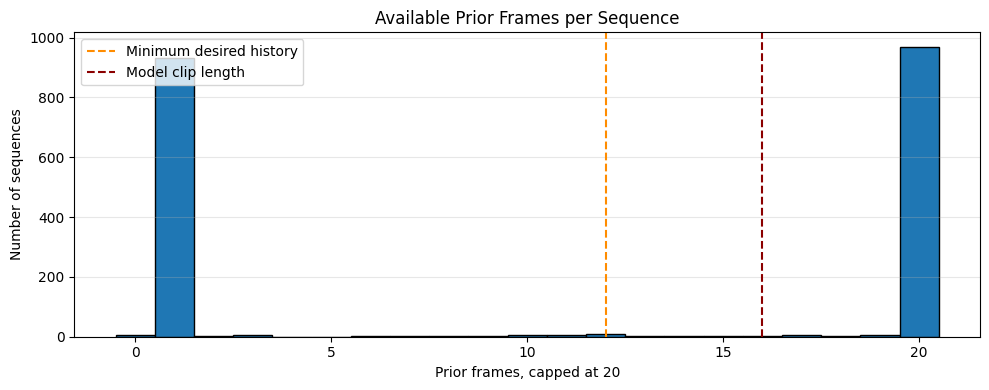

In [5]:
def select_prior_frame_paths(target_path_value):
    target_path = resolve_frame_path(target_path_value)
    parsed_target = parse_frame_name(target_path)

    if parsed_target is None:
        raise ValueError(
            f'Target filename does not end in a numeric '
            f'frame index: {target_path.name}'
        )

    sequence_id, target_frame_index = parsed_target
    inventory_key = (
        str(target_path.parent.resolve()),
        sequence_id,
    )

    sequence_frames = frame_inventory.get(inventory_key)
    if sequence_frames is None:
        raise KeyError(
            f'No frame inventory found for sequence '
            f'{sequence_id} in {target_path.parent}.'
        )

    # Strictly exclude the target frame and every later frame.
    prior_frames = [
        (frame_index, frame_path)
        for frame_index, frame_path in sequence_frames
        if frame_index < target_frame_index
    ]

    recent_prior_frames = prior_frames[
        -MAX_LOOKBACK_FRAMES:
    ]
    available_in_window = len(recent_prior_frames)

    if available_in_window >= CLIP_LENGTH:
        # Uniformly cover the recent source window while keeping
        # chronological order.
        sample_positions = np.linspace(
            0,
            available_in_window - 1,
            num=CLIP_LENGTH,
        )
        sample_positions = np.rint(
            sample_positions
        ).astype(int)

        selected_frames = [
            recent_prior_frames[position]
            for position in sample_positions
        ]
        padded_frame_count = 0
        used_black_padding = False

    elif available_in_window > 0:
        # Repeat only the earliest eligible prior frame. No target or
        # future frame is introduced.
        padded_frame_count = (
            CLIP_LENGTH - available_in_window
        )
        earliest_prior_frame = recent_prior_frames[0]
        selected_frames = (
            [earliest_prior_frame] * padded_frame_count
            + recent_prior_frames
        )
        used_black_padding = False

    else:
        # A first-frame target has no legal image history.
        padded_frame_count = CLIP_LENGTH
        selected_frames = [
            (None, None)
            for _ in range(CLIP_LENGTH)
        ]
        used_black_padding = True

    selected_indices = [
        frame_index
        for frame_index, _ in selected_frames
        if frame_index is not None
    ]

    if any(
        frame_index >= target_frame_index
        for frame_index in selected_indices
    ):
        raise AssertionError(
            f'Non-prior frame selected for {target_path.name}.'
        )

    selected_paths = [
        frame_path
        for _, frame_path in selected_frames
    ]

    metadata = {
        'sequence_id': sequence_id,
        'target_frame_index': target_frame_index,
        'available_prior_frames': len(prior_frames),
        'source_window_frames': available_in_window,
        'unique_selected_frames': len(
            set(selected_indices)
        ),
        'padded_frames': padded_frame_count,
        'used_black_padding': used_black_padding,
    }

    return selected_paths, metadata


clip_selections = {}
clip_metadata_dfs = {}

for split_name in SPLIT_NAMES:
    split_selections = []
    metadata_rows = []

    for row_index, row in split_dfs[
        split_name
    ].iterrows():
        selected_paths, metadata = (
            select_prior_frame_paths(
                row['target_frame_path']
            )
        )

        split_selections.append(selected_paths)
        metadata_rows.append({
            'split': split_name,
            'row_index': row_index,
            'target_frame_path': (
                row['target_frame_path']
            ),
            'class_label': row['class_label'],
            **metadata,
        })

    clip_selections[split_name] = split_selections
    clip_metadata_dfs[split_name] = pd.DataFrame(
        metadata_rows
    )

full_clip_metadata_df = pd.concat(
    clip_metadata_dfs.values(),
    ignore_index=True,
)

history_summary_rows = []

for split_name in SPLIT_NAMES:
    metadata_df = clip_metadata_dfs[split_name]
    available = metadata_df['available_prior_frames']

    history_summary_rows.append({
        'split': split_name,
        'sequences': len(metadata_df),
        'no_prior_frames': int((available == 0).sum()),
        'fewer_than_12': int(
            (available < MIN_DESIRED_PRIOR_FRAMES).sum()
        ),
        '12_to_15': int(
            (
                (available >= 12)
                & (available <= 15)
            ).sum()
        ),
        '16_to_19': int(
            (
                (available >= 16)
                & (available <= 19)
            ).sum()
        ),
        '20_or_more': int((available >= 20).sum()),
        'padded_sequences': int(
            (metadata_df['padded_frames'] > 0).sum()
        ),
    })

print('Prior-frame availability summary:')
display(pd.DataFrame(history_summary_rows))

plt.figure(figsize=(10, 4))
plt.hist(
    np.minimum(
        full_clip_metadata_df[
            'available_prior_frames'
        ],
        MAX_LOOKBACK_FRAMES,
    ),
    bins=np.arange(
        -0.5,
        MAX_LOOKBACK_FRAMES + 1.5,
        1,
    ),
    edgecolor='black',
)
plt.axvline(
    MIN_DESIRED_PRIOR_FRAMES,
    color='darkorange',
    linestyle='--',
    label='Minimum desired history',
)
plt.axvline(
    CLIP_LENGTH,
    color='darkred',
    linestyle='--',
    label='Model clip length',
)
plt.title('Available Prior Frames per Sequence')
plt.xlabel(
    f'Prior frames, capped at {MAX_LOOKBACK_FRAMES}'
)
plt.ylabel('Number of sequences')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Step 5: Build and cache resized RGB clips

Each cache is a binary uint8 array with shape:

`(sequences, time, height, width, channels)`

A memory-mapped writer creates the cache incrementally, so all clips do
not need to fit in RAM during preprocessing. If the temporal or spatial
settings change, set `OVERWRITE_CLIP_CACHE=True` and rerun this section.

In [6]:
def load_image(frame_path):
    # The first modality is the camera panorama in these files.
    with np.load(
        frame_path,
        allow_pickle=True,
    ) as frame_data:
        modality = frame_data[
            '_modality_data'
        ].item()
        modality_keys = list(modality.keys())
        image = np.asarray(
            modality[modality_keys[0]]
        )

    if np.issubdtype(image.dtype, np.floating):
        if image.max() <= 1.0:
            image = image * 255.0
        image = np.clip(
            image,
            0,
            255,
        ).astype(np.uint8)
    else:
        image = image.astype(np.uint8)

    return image


def prepare_frame(frame_path):
    image = load_image(frame_path)

    if image.ndim == 2:
        image = np.repeat(
            image[:, :, np.newaxis],
            3,
            axis=2,
        )

    if image.shape[-1] == 4:
        image = image[:, :, :3]

    if image.ndim != 3 or image.shape[-1] != 3:
        raise ValueError(
            f'Unexpected image shape at {frame_path}: '
            f'{image.shape}'
        )

    image_tensor = tf.convert_to_tensor(
        image,
        dtype=tf.float32,
    )
    image_tensor = tf.image.resize(
        image_tensor,
        size=(IMAGE_HEIGHT, IMAGE_WIDTH),
        method='bilinear',
        antialias=True,
    )

    return np.clip(
        np.rint(image_tensor.numpy()),
        0,
        255,
    ).astype(np.uint8)


def build_clip(selected_paths):
    if len(selected_paths) != CLIP_LENGTH:
        raise ValueError(
            f'Expected {CLIP_LENGTH} selected paths; '
            f'received {len(selected_paths)}.'
        )

    black_frame = np.zeros(
        (
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
            IMAGE_CHANNELS,
        ),
        dtype=np.uint8,
    )

    # Repeated padding paths are decoded only once per clip.
    prepared_frame_cache = {}
    clip_frames = []

    for selected_path in selected_paths:
        if selected_path is None:
            clip_frames.append(black_frame)
            continue

        cache_key = str(selected_path)
        if cache_key not in prepared_frame_cache:
            prepared_frame_cache[cache_key] = (
                prepare_frame(selected_path)
            )

        clip_frames.append(
            prepared_frame_cache[cache_key]
        )

    return np.stack(clip_frames)

In [7]:
current_cache_config = {
    'clip_length': CLIP_LENGTH,
    'max_lookback_frames': MAX_LOOKBACK_FRAMES,
    'image_height': IMAGE_HEIGHT,
    'image_width': IMAGE_WIDTH,
    'image_channels': IMAGE_CHANNELS,
    'split_rows': {
        split_name: len(split_dfs[split_name])
        for split_name in SPLIT_NAMES
    },
    'split_fingerprints': {
        split_name: hashlib.sha256(
            split_dfs[split_name][[
                'target_frame_path',
                'class_label',
            ]]
            .to_csv(index=False)
            .encode('utf-8')
        ).hexdigest()
        for split_name in SPLIT_NAMES
    },
}

estimated_cache_bytes = sum(
    len(split_dfs[split_name])
    * int(np.prod(INPUT_SHAPE))
    for split_name in SPLIT_NAMES
)
print(
    f'Estimated total uint8 clip-cache size: '
    f'{estimated_cache_bytes / (1024 ** 3):.3f} GB'
)

if CACHE_CONFIG_PATH.exists():
    with open(
        CACHE_CONFIG_PATH,
        'r',
        encoding='utf-8',
    ) as cache_config_file:
        saved_cache_config = json.load(
            cache_config_file
        )

    if (
        saved_cache_config != current_cache_config
        and not OVERWRITE_CLIP_CACHE
    ):
        raise ValueError(
            'The existing clip cache uses different settings. '
            'Set OVERWRITE_CLIP_CACHE=True to rebuild it.'
        )


def create_clip_cache(
    split_name,
    cache_path,
    selections,
    overwrite=False,
):
    expected_shape = (
        len(selections),
        CLIP_LENGTH,
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
        IMAGE_CHANNELS,
    )

    if cache_path.exists() and not overwrite:
        cached_array = np.load(
            cache_path,
            mmap_mode='r',
        )

        if (
            cached_array.shape != expected_shape
            or cached_array.dtype != np.uint8
        ):
            raise ValueError(
                f'{cache_path.name} has shape '
                f'{cached_array.shape} and dtype '
                f'{cached_array.dtype}; expected '
                f'{expected_shape} and uint8.'
            )

        print(
            f'{cache_path.name} already exists with '
            f'the expected shape. Skipping rebuild.'
        )
        del cached_array
        return

    start_time = time.perf_counter()

    partial_cache_path = cache_path.with_suffix(
        '.partial.npy'
    )
    if partial_cache_path.exists():
        partial_cache_path.unlink()

    clip_cache = np.lib.format.open_memmap(
        partial_cache_path,
        mode='w+',
        dtype=np.uint8,
        shape=expected_shape,
    )

    for row_index, selected_paths in enumerate(
        selections
    ):
        clip_cache[row_index] = build_clip(
            selected_paths
        )

        completed_rows = row_index + 1
        if (
            completed_rows % 50 == 0
            or completed_rows == len(selections)
        ):
            print(
                f'  {split_name}: '
                f'{completed_rows:,}/{len(selections):,} '
                'clips cached'
            )

    clip_cache.flush()
    del clip_cache

    # Publish the cache only after every row is complete.
    partial_cache_path.replace(cache_path)

    elapsed_minutes = (
        time.perf_counter() - start_time
    ) / 60
    file_size_gb = (
        cache_path.stat().st_size
        / (1024 ** 3)
    )

    print(
        f'Created {cache_path.name}: '
        f'{file_size_gb:.3f} GB in '
        f'{elapsed_minutes:.2f} minutes'
    )


for split_name in SPLIT_NAMES:
    create_clip_cache(
        split_name=split_name,
        cache_path=CLIP_CACHE_PATHS[split_name],
        selections=clip_selections[split_name],
        overwrite=OVERWRITE_CLIP_CACHE,
    )

    clip_metadata_dfs[split_name].to_csv(
        CLIP_METADATA_PATHS[split_name],
        index=False,
    )

with open(
    CACHE_CONFIG_PATH,
    'w',
    encoding='utf-8',
) as cache_config_file:
    json.dump(
        current_cache_config,
        cache_config_file,
        indent=2,
    )

clip_arrays = {}

for split_name in SPLIT_NAMES:
    clip_array = np.load(
        CLIP_CACHE_PATHS[split_name],
        mmap_mode='r',
    )
    clip_arrays[split_name] = clip_array

    print(
        f'{split_name}: shape={clip_array.shape}, '
        f'dtype={clip_array.dtype}, '
        f'disk={clip_array.nbytes / (1024 ** 3):.3f} GB'
    )

Estimated total uint8 clip-cache size: 0.900 GB
  train: 50/1,376 clips cached
  train: 100/1,376 clips cached
  train: 150/1,376 clips cached
  train: 200/1,376 clips cached
  train: 250/1,376 clips cached
  train: 300/1,376 clips cached
  train: 350/1,376 clips cached
  train: 400/1,376 clips cached
  train: 450/1,376 clips cached
  train: 500/1,376 clips cached
  train: 550/1,376 clips cached
  train: 600/1,376 clips cached
  train: 650/1,376 clips cached
  train: 700/1,376 clips cached
  train: 750/1,376 clips cached
  train: 800/1,376 clips cached
  train: 850/1,376 clips cached
  train: 900/1,376 clips cached
  train: 950/1,376 clips cached
  train: 1,000/1,376 clips cached
  train: 1,050/1,376 clips cached
  train: 1,100/1,376 clips cached
  train: 1,150/1,376 clips cached
  train: 1,200/1,376 clips cached
  train: 1,250/1,376 clips cached
  train: 1,300/1,376 clips cached
  train: 1,350/1,376 clips cached
  train: 1,376/1,376 clips cached
Created X_train_clips.npy: 0.630 GB in 

# Step 6: Show one prior-only example GIF from each class

The example with the most available history is selected for each class.
Each GIF ends immediately before its target frame.

### straight
Available prior frames: 203; padded frames: 0

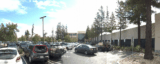

### right-turn
Available prior frames: 226; padded frames: 0

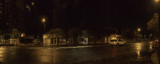

### left-turn
Available prior frames: 227; padded frames: 0

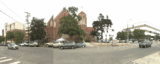

In [8]:
for class_id, class_name in enumerate(CLASS_NAMES):
    class_rows = clip_metadata_dfs['train'].loc[
        y_train == class_id
    ]
    example_index = int(
        class_rows.sort_values(
            'available_prior_frames',
            ascending=False,
        ).iloc[0]['row_index']
    )

    example_clip = np.asarray(
        clip_arrays['train'][example_index]
    )
    example_metadata = clip_metadata_dfs[
        'train'
    ].iloc[example_index]

    gif_path = (
        GIF_OUTPUT_DIR
        / f'{class_name}_prior_frames.gif'
    )

    imageio.mimsave(
        gif_path,
        list(example_clip),
        format='GIF',
        duration=0.18,
        loop=0,
    )

    display(Markdown(
        f'### {class_name}\n'
        f'Available prior frames: '
        f'{int(example_metadata["available_prior_frames"])}; '
        f'padded frames: '
        f'{int(example_metadata["padded_frames"])}'
    ))
    display(
        IPythonImage(
            filename=str(gif_path),
            width=800,
        )
    )

# Step 7: Stream memory-mapped clips in small batches

A custom Keras `Sequence` reads only the clips needed for the current
batch. This avoids copying the entire binary cache into memory.

If training produces a GPU out-of-memory error, reduce the configured
batch size from 4 to 2.

In [9]:
class ClipSequence(tf.keras.utils.Sequence):
    def __init__(
        self,
        cache_path,
        labels,
        batch_size,
        shuffle,
        seed,
    ):
        super().__init__()

        self.cache_path = Path(cache_path)
        self.clips = np.load(
            self.cache_path,
            mmap_mode='r',
        )
        self.labels = np.asarray(
            labels,
            dtype=np.int32,
        )
        self.batch_size = int(batch_size)
        self.shuffle = bool(shuffle)
        self.rng = np.random.default_rng(seed)
        self.indices = np.arange(len(self.labels))

        if len(self.clips) != len(self.labels):
            raise ValueError(
                f'{self.cache_path.name} has '
                f'{len(self.clips)} clips but '
                f'{len(self.labels)} labels.'
            )

        self.on_epoch_end()

    def __len__(self):
        return math.ceil(
            len(self.labels) / self.batch_size
        )

    def __getitem__(self, batch_index):
        batch_start = batch_index * self.batch_size
        batch_end = min(
            batch_start + self.batch_size,
            len(self.labels),
        )
        batch_indices = self.indices[
            batch_start:batch_end
        ]

        # Fancy indexing copies only the current batch from disk.
        batch_clips = np.asarray(
            self.clips[batch_indices],
            dtype=np.uint8,
        )
        batch_labels = self.labels[batch_indices]

        return batch_clips, batch_labels

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.indices)


inspection_sequence = ClipSequence(
    cache_path=CLIP_CACHE_PATHS['train'],
    labels=y_train,
    batch_size=2,
    shuffle=False,
    seed=SEED,
)

inspection_clips, inspection_labels = (
    inspection_sequence[0]
)

print(f'Example batch shape: {inspection_clips.shape}')
print(f'Example batch dtype: {inspection_clips.dtype}')
print(f'Example labels: {inspection_labels}')

del inspection_sequence
del inspection_clips
gc.collect()

Example batch shape: (2, 16, 64, 160, 3)
Example batch dtype: uint8
Example labels: [1 0]


71

# Step 8: Define evaluation and plotting functions

Macro metrics weight all three maneuver classes equally. Sensitivity is
reported as macro recall because class-specific sensitivity is recall.

In [10]:
def calculate_metrics(y_true, y_pred, model_name):
    recall_macro = recall_score(
        y_true,
        y_pred,
        average='macro',
        zero_division=0,
    )

    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0,
        ),
        'recall_macro': recall_macro,
        'sensitivity_macro': recall_macro,
        'f1_macro': f1_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0,
        ),
        'precision_weighted': precision_score(
            y_true,
            y_pred,
            average='weighted',
            zero_division=0,
        ),
        'recall_weighted': recall_score(
            y_true,
            y_pred,
            average='weighted',
            zero_division=0,
        ),
        'f1_weighted': f1_score(
            y_true,
            y_pred,
            average='weighted',
            zero_division=0,
        ),
    }


def classification_report_df(y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).T


def plot_confusion_matrices(
    y_true,
    y_pred,
    model_name,
):
    count_matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
    )
    normalized_matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        normalize='true',
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(13, 5),
    )

    ConfusionMatrixDisplay(
        confusion_matrix=count_matrix,
        display_labels=CLASS_NAMES,
    ).plot(
        ax=axes[0],
        cmap='Blues',
        colorbar=False,
        values_format='d',
    )
    axes[0].set_title(
        f'{model_name}: Count Confusion Matrix'
    )
    axes[0].tick_params(
        axis='x',
        rotation=25,
    )

    ConfusionMatrixDisplay(
        confusion_matrix=normalized_matrix,
        display_labels=CLASS_NAMES,
    ).plot(
        ax=axes[1],
        cmap='Blues',
        colorbar=False,
        values_format='.2f',
    )
    axes[1].set_title(
        f'{model_name}: Row-Normalized Matrix'
    )
    axes[1].tick_params(
        axis='x',
        rotation=25,
    )

    plt.tight_layout()
    plt.show()


def plot_training_history(history, title):
    history_values = (
        history.history
        if hasattr(history, 'history')
        else history
    )
    epoch_values = np.arange(
        1,
        len(history_values['loss']) + 1,
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(13, 4),
    )

    axes[0].plot(
        epoch_values,
        history_values['loss'],
        marker='o',
        label='Training loss',
    )
    axes[0].plot(
        epoch_values,
        history_values['val_loss'],
        marker='o',
        label='Validation loss',
    )
    axes[0].set_title(f'{title}: Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(
        epoch_values,
        history_values['accuracy'],
        marker='o',
        label='Training accuracy',
    )
    axes[1].plot(
        epoch_values,
        history_values['val_accuracy'],
        marker='o',
        label='Validation accuracy',
    )
    axes[1].set_title(f'{title}: Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Step 9: Put the custom TensorFlow 3D CNN into a tunable function

The model uses true 3D convolutions with kernels that move through time
and space. The first pooling layer preserves all temporal positions;
later pooling layers reduce both time and space.

Batch normalization is intentionally omitted because the 2D diagnostic
tests showed a large training/inference mismatch on this dataset.
Coarse temporal-spatial pooling followed by flattening preserves where
and when learned features occur.

In [11]:
MODEL_CONFIG_KEYS = [
    'conv_filters',
    'spatial_kernel_size',
    'temporal_kernel_size',
    'dense_units',
    'dropout_rate',
    'learning_rate',
    'l2_strength',
]


def build_3d_cnn_model(
    input_shape,
    conv_filters=(8, 16, 32),
    spatial_kernel_size=3,
    temporal_kernel_size=3,
    dense_units=64,
    dropout_rate=0.25,
    learning_rate=0.001,
    l2_strength=0.0001,
):
    inputs = tf.keras.Input(
        shape=input_shape,
        name='prior_rgb_clip',
    )

    x = tf.keras.layers.Rescaling(
        scale=1.0 / 255.0,
        name='pixel_rescaling',
    )(inputs)

    for block_number, filter_count in enumerate(
        conv_filters,
        start=1,
    ):
        x = tf.keras.layers.Conv3D(
            filters=filter_count,
            kernel_size=(
                temporal_kernel_size,
                spatial_kernel_size,
                spatial_kernel_size,
            ),
            padding='same',
            use_bias=True,
            kernel_initializer='he_normal',
            kernel_regularizer=(
                tf.keras.regularizers.l2(
                    l2_strength
                )
            ),
            name=f'conv3d_{block_number}',
        )(x)
        x = tf.keras.layers.ReLU(
            name=f'relu_{block_number}',
        )(x)

        # Preserve all temporal samples in the first block.
        pool_size = (
            (1, 2, 2)
            if block_number == 1
            else (2, 2, 2)
        )
        x = tf.keras.layers.MaxPooling3D(
            pool_size=pool_size,
            name=f'max_pool3d_{block_number}',
        )(x)
        x = tf.keras.layers.Dropout(
            rate=dropout_rate / 2,
            name=f'conv_dropout_{block_number}',
        )(x)

    # Preserve a coarse time-height-width grid instead of globally
    # averaging away maneuver direction and temporal position.
    x = tf.keras.layers.AveragePooling3D(
        pool_size=(2, 2, 4),
        name='coarse_spatiotemporal_pool',
    )(x)
    x = tf.keras.layers.Flatten(
        name='flatten',
    )(x)
    x = tf.keras.layers.Dense(
        units=dense_units,
        activation='relu',
        kernel_initializer='he_normal',
        kernel_regularizer=(
            tf.keras.regularizers.l2(
                l2_strength
            )
        ),
        name='dense_hidden',
    )(x)
    x = tf.keras.layers.Dropout(
        rate=dropout_rate,
        name='dense_dropout',
    )(x)

    outputs = tf.keras.layers.Dense(
        units=NUM_CLASSES,
        activation='softmax',
        name='class_probabilities',
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name='waymo_3d_cnn',
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
        ),
        loss=(
            tf.keras.losses
            .SparseCategoricalCrossentropy()
        ),
        metrics=['accuracy'],
    )

    return model


def build_model_from_config(config):
    model_kwargs = {
        key: config[key]
        for key in MODEL_CONFIG_KEYS
    }

    return build_3d_cnn_model(
        input_shape=INPUT_SHAPE,
        **model_kwargs,
    )

In [12]:
def count_model_parameters(model):
    trainable_parameters = int(sum(
        np.prod(variable.shape)
        for variable in model.trainable_weights
    ))
    non_trainable_parameters = int(sum(
        np.prod(variable.shape)
        for variable in model.non_trainable_weights
    ))

    return {
        'total_parameters': int(model.count_params()),
        'trainable_parameters': trainable_parameters,
        'non_trainable_parameters': (
            non_trainable_parameters
        ),
    }


def selection_score(result_record):
    # Prefer balanced three-class performance, then accuracy,
    # then lower validation loss.
    return (
        result_record['validation_f1_macro'],
        result_record['validation_accuracy'],
        -result_record['validation_loss'],
    )


def make_clip_sequence(
    split_name,
    batch_size,
    shuffle,
    seed,
):
    return ClipSequence(
        cache_path=CLIP_CACHE_PATHS[split_name],
        labels=y_by_split[split_name],
        batch_size=batch_size,
        shuffle=shuffle,
        seed=seed,
    )


def train_and_validate_model(
    config,
    trial_name,
    max_epochs=20,
    patience=5,
):
    print('=' * 100)
    print(f'TRIAL: {trial_name}')
    print('Hyperparameters:')
    for parameter_name, parameter_value in config.items():
        print(
            f'  {parameter_name}: {parameter_value}'
        )

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    model = build_model_from_config(config)

    print('\nModel summary:')
    model.summary()

    parameter_counts = count_model_parameters(model)
    print('\nParameter counts:')
    for parameter_name, parameter_value in (
        parameter_counts.items()
    ):
        print(
            f'  {parameter_name}: '
            f'{parameter_value:,}'
        )

    train_sequence = make_clip_sequence(
        split_name='train',
        batch_size=config['batch_size'],
        shuffle=True,
        seed=SEED,
    )
    validation_sequence = make_clip_sequence(
        split_name='val',
        batch_size=config['batch_size'],
        shuffle=False,
        seed=SEED,
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            mode='min',
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            mode='min',
            factor=0.5,
            patience=max(2, patience // 2),
            min_lr=1e-6,
            verbose=1,
        ),
        tf.keras.callbacks.TerminateOnNaN(),
    ]

    start_time = time.perf_counter()

    history = model.fit(
        train_sequence,
        validation_data=validation_sequence,
        epochs=max_epochs,
        callbacks=callbacks,
        verbose=1,
    )

    elapsed_seconds = (
        time.perf_counter() - start_time
    )

    validation_results = model.evaluate(
        validation_sequence,
        verbose=1,
        return_dict=True,
    )
    validation_probabilities = model.predict(
        validation_sequence,
        verbose=1,
    )
    validation_predictions = np.argmax(
        validation_probabilities,
        axis=1,
    )

    validation_metrics = calculate_metrics(
        y_val,
        validation_predictions,
        trial_name,
    )
    best_epoch = int(
        np.argmin(history.history['val_loss']) + 1
    )

    result_record = {
        'trial': trial_name,
        'conv_filters': str(
            config['conv_filters']
        ),
        'spatial_kernel_size': (
            config['spatial_kernel_size']
        ),
        'temporal_kernel_size': (
            config['temporal_kernel_size']
        ),
        'dense_units': config['dense_units'],
        'dropout_rate': config['dropout_rate'],
        'learning_rate': config['learning_rate'],
        'l2_strength': config['l2_strength'],
        'batch_size': config['batch_size'],
        'epochs_run': len(
            history.history['loss']
        ),
        'best_epoch': best_epoch,
        'total_parameters': (
            parameter_counts['total_parameters']
        ),
        'validation_loss': (
            validation_results['loss']
        ),
        'validation_accuracy': (
            validation_results['accuracy']
        ),
        'validation_precision_macro': (
            validation_metrics['precision_macro']
        ),
        'validation_recall_macro': (
            validation_metrics['recall_macro']
        ),
        'validation_sensitivity_macro': (
            validation_metrics['sensitivity_macro']
        ),
        'validation_f1_macro': (
            validation_metrics['f1_macro']
        ),
        'training_seconds': elapsed_seconds,
    }

    print('\nRestored-model validation results:')
    for metric_name, metric_value in (
        result_record.items()
    ):
        print(f'  {metric_name}: {metric_value}')

    plot_training_history(history, trial_name)

    del train_sequence
    del validation_sequence
    gc.collect()

    return model, history, result_record

# Step 10: Train the initial custom 3D CNN

This establishes a compact starting model. Training uses only the
training clip cache and monitors the validation cache.

TRIAL: Initial 3D CNN
Hyperparameters:
  conv_filters: (8, 16, 32)
  spatial_kernel_size: 3
  temporal_kernel_size: 3
  dense_units: 64
  dropout_rate: 0.25
  learning_rate: 0.001
  l2_strength: 0.0001
  batch_size: 4


Model summary:


Model: "waymo_3d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ prior_rgb_clip (InputLayer)          │ (None, 16, 64, 160, 3)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_rescaling (Rescaling)          │ (None, 16, 64, 160, 3)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_1 (Conv3D)                    │ (None, 16, 64, 160, 8)      │             656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_1 (ReLU)                        │ (None, 16, 64, 160, 8)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_1 (MaxPooling3D)          │ (None, 16, 32, 80, 8)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_1 (Dropout)             │ (None, 16, 32, 80, 8)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_2 (Conv3D)                    │ (None, 16, 32, 80, 16)      │           3,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_2 (ReLU)                        │ (None, 16, 32, 80, 16)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_2 (MaxPooling3D)          │ (None, 8, 16, 40, 16)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_2 (Dropout)             │ (None, 8, 16, 40, 16)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_3 (Conv3D)                    │ (None, 8, 16, 40, 32)       │          13,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_3 (ReLU)                        │ (None, 8, 16, 40, 32)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_3 (MaxPooling3D)          │ (None, 4, 8, 20, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_3 (Dropout)             │ (None, 4, 8, 20, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ coarse_spatiotemporal_pool           │ (None, 2, 4, 5, 32)         │               0 │
│ (AveragePooling3D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_hidden (Dense)                 │ (None, 64)                  │          81,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_dropout (Dropout)              │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ class_probabilities (Dense)          │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 100,163 (391.26 KB)

 Trainable params: 100,163 (391.26 KB)

 Non-trainable params: 0 (0.00 B)


Parameter counts:
  total_parameters: 100,163
  trainable_parameters: 100,163
  non_trainable_parameters: 0
Epoch 1/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 30s 80ms/step - accuracy: 0.4477 - loss: 1.1196 - val_accuracy: 0.4610 - val_loss: 1.0825 - learning_rate: 0.0010
Epoch 2/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 27s 79ms/step - accuracy: 0.4629 - loss: 1.0785 - val_accuracy: 0.4610 - val_loss: 1.0738 - learning_rate: 0.0010
Epoch 3/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 27s 79ms/step - accuracy: 0.4571 - loss: 1.0649 - val_accuracy: 0.4610 - val_loss: 1.0509 - learning_rate: 0.0010
Epoch 4/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 27s 79ms/step - accuracy: 0.5283 - loss: 1.0022 - val_accuracy: 0.5051 - val_loss: 0.9746 - learning_rate: 0.0010
Epoch 5/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 27s 79ms/step - accuracy: 0.5705 - loss: 0.9197 - val_accuracy: 0.5288 - val_loss: 0.9623 - learning_rate: 0.0010
Epoch 6/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 28s 81ms/step - accuracy: 0.6148 - loss: 0.8447 - val_accuracy: 0.6305 - val_loss

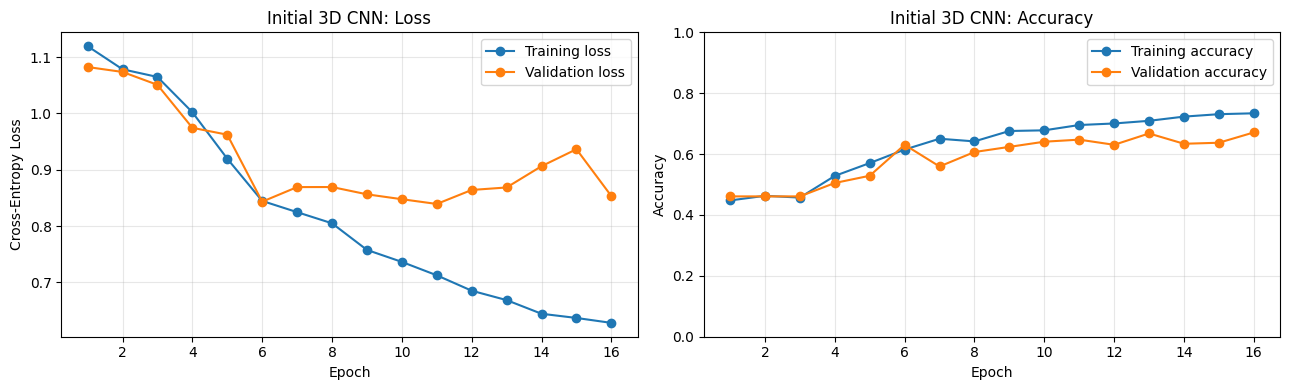

0

In [13]:
INITIAL_CONFIG = {
    'conv_filters': (8, 16, 32),
    'spatial_kernel_size': 3,
    'temporal_kernel_size': 3,
    'dense_units': 64,
    'dropout_rate': 0.25,
    'learning_rate': 0.001,
    'l2_strength': 0.0001,
    'batch_size': 4,
}

INITIAL_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5

initial_model, initial_history, initial_result = (
    train_and_validate_model(
        config=INITIAL_CONFIG,
        trial_name='Initial 3D CNN',
        max_epochs=INITIAL_EPOCHS,
        patience=EARLY_STOPPING_PATIENCE,
    )
)

tuning_records = [initial_result]
best_score = selection_score(initial_result)
best_config = INITIAL_CONFIG.copy()
best_trial_name = 'Initial 3D CNN'
best_weights = [
    weight.copy()
    for weight in initial_model.get_weights()
]
best_history = {
    key: values.copy()
    for key, values
    in initial_history.history.items()
}

del initial_model
gc.collect()

# Step 11: Tune 3D CNN hyperparameters on the validation split

The compact search tests:

- convolution width;
- learning rate;
- dropout and L2 regularization;
- spatial receptive field; and
- dense-head capacity.

The temporal kernel remains three frames in every trial so the search
remains computationally manageable. The test split is not used for
model or hyperparameter selection.

In [14]:
TUNING_EPOCHS = 40

TUNING_CONFIGS = [
    {
        'name': 'Medium 3D capacity',
        'conv_filters': (16, 32, 64),
        'spatial_kernel_size': 3,
        'temporal_kernel_size': 3,
        'dense_units': 64,
        'dropout_rate': 0.30,
        'learning_rate': 0.001,
        'l2_strength': 0.0001,
        'batch_size': 4,
    },
    {
        'name': 'Medium 3D lower learning rate',
        'conv_filters': (16, 32, 64),
        'spatial_kernel_size': 3,
        'temporal_kernel_size': 3,
        'dense_units': 64,
        'dropout_rate': 0.30,
        'learning_rate': 0.0003,
        'l2_strength': 0.0001,
        'batch_size': 4,
    },
    {
        'name': 'Stronger 3D regularization',
        'conv_filters': (16, 32, 64),
        'spatial_kernel_size': 3,
        'temporal_kernel_size': 3,
        'dense_units': 64,
        'dropout_rate': 0.45,
        'learning_rate': 0.0003,
        'l2_strength': 0.0005,
        'batch_size': 4,
    },
    {
        'name': 'Wider spatial kernel',
        'conv_filters': (8, 16, 32),
        'spatial_kernel_size': 5,
        'temporal_kernel_size': 3,
        'dense_units': 64,
        'dropout_rate': 0.30,
        'learning_rate': 0.0003,
        'l2_strength': 0.0001,
        'batch_size': 4,
    },
    {
        'name': 'Larger 3D dense head',
        'conv_filters': (16, 32, 64),
        'spatial_kernel_size': 3,
        'temporal_kernel_size': 3,
        'dense_units': 128,
        'dropout_rate': 0.40,
        'learning_rate': 0.0003,
        'l2_strength': 0.0001,
        'batch_size': 4,
    },
]

print(
    f'Additional tuning trials: '
    f'{len(TUNING_CONFIGS)}'
)

for trial_number, trial_config in enumerate(
    TUNING_CONFIGS,
    start=1,
):
    print(
        f'\nTrial {trial_number}: '
        f'{trial_config["name"]}'
    )
    for parameter_name, parameter_value in (
        trial_config.items()
    ):
        if parameter_name != 'name':
            print(
                f'  {parameter_name}: '
                f'{parameter_value}'
            )

Additional tuning trials: 5

Trial 1: Medium 3D capacity
  conv_filters: (16, 32, 64)
  spatial_kernel_size: 3
  temporal_kernel_size: 3
  dense_units: 64
  dropout_rate: 0.3
  learning_rate: 0.001
  l2_strength: 0.0001
  batch_size: 4

Trial 2: Medium 3D lower learning rate
  conv_filters: (16, 32, 64)
  spatial_kernel_size: 3
  temporal_kernel_size: 3
  dense_units: 64
  dropout_rate: 0.3
  learning_rate: 0.0003
  l2_strength: 0.0001
  batch_size: 4

Trial 3: Stronger 3D regularization
  conv_filters: (16, 32, 64)
  spatial_kernel_size: 3
  temporal_kernel_size: 3
  dense_units: 64
  dropout_rate: 0.45
  learning_rate: 0.0003
  l2_strength: 0.0005
  batch_size: 4

Trial 4: Wider spatial kernel
  conv_filters: (8, 16, 32)
  spatial_kernel_size: 5
  temporal_kernel_size: 3
  dense_units: 64
  dropout_rate: 0.3
  learning_rate: 0.0003
  l2_strength: 0.0001
  batch_size: 4

Trial 5: Larger 3D dense head
  conv_filters: (16, 32, 64)
  spatial_kernel_size: 3
  temporal_kernel_size: 3
  den

TRIAL: Medium 3D capacity
Hyperparameters:
  conv_filters: (16, 32, 64)
  spatial_kernel_size: 3
  temporal_kernel_size: 3
  dense_units: 64
  dropout_rate: 0.3
  learning_rate: 0.001
  l2_strength: 0.0001
  batch_size: 4

Model summary:


Model: "waymo_3d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ prior_rgb_clip (InputLayer)          │ (None, 16, 64, 160, 3)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_rescaling (Rescaling)          │ (None, 16, 64, 160, 3)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_1 (Conv3D)                    │ (None, 16, 64, 160, 16)     │           1,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_1 (ReLU)                        │ (None, 16, 64, 160, 16)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_1 (MaxPooling3D)          │ (None, 16, 32, 80, 16)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_1 (Dropout)             │ (None, 16, 32, 80, 16)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_2 (Conv3D)                    │ (None, 16, 32, 80, 32)      │          13,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_2 (ReLU)                        │ (None, 16, 32, 80, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_2 (MaxPooling3D)          │ (None, 8, 16, 40, 32)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_2 (Dropout)             │ (None, 8, 16, 40, 32)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_3 (Conv3D)                    │ (None, 8, 16, 40, 64)       │          55,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_3 (ReLU)                        │ (None, 8, 16, 40, 64)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_3 (MaxPooling3D)          │ (None, 4, 8, 20, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_3 (Dropout)             │ (None, 4, 8, 20, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ coarse_spatiotemporal_pool           │ (None, 2, 4, 5, 64)         │               0 │
│ (AveragePooling3D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2560)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_hidden (Dense)                 │ (None, 64)                  │         163,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_dropout (Dropout)              │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ class_probabilities (Dense)          │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 234,627 (916.51 KB)

 Trainable params: 234,627 (916.51 KB)

 Non-trainable params: 0 (0.00 B)


Parameter counts:
  total_parameters: 234,627
  trainable_parameters: 234,627
  non_trainable_parameters: 0
Epoch 1/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 60s 170ms/step - accuracy: 0.4433 - loss: 1.1546 - val_accuracy: 0.4610 - val_loss: 1.0946 - learning_rate: 0.0010
Epoch 2/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 59s 172ms/step - accuracy: 0.4578 - loss: 1.0938 - val_accuracy: 0.4610 - val_loss: 1.0954 - learning_rate: 0.0010
Epoch 3/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 62s 181ms/step - accuracy: 0.4608 - loss: 1.0912 - val_accuracy: 0.4610 - val_loss: 1.0894 - learning_rate: 0.0010
Epoch 4/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 59s 173ms/step - accuracy: 0.4608 - loss: 1.0641 - val_accuracy: 0.4610 - val_loss: 1.0312 - learning_rate: 0.0010
Epoch 5/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 63s 183ms/step - accuracy: 0.5145 - loss: 0.9745 - val_accuracy: 0.5322 - val_loss: 0.9592 - learning_rate: 0.0010
Epoch 6/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 58s 170ms/step - accuracy: 0.5908 - loss: 0.9182 - val_accuracy: 0.6068 - va

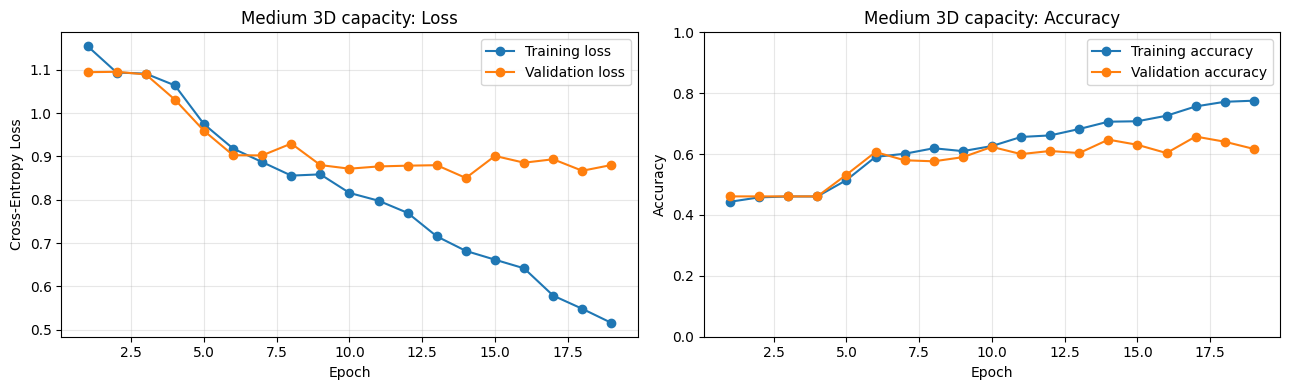


New best validation model: Medium 3D capacity
Completed tuning trial 1/5
TRIAL: Medium 3D lower learning rate
Hyperparameters:
  conv_filters: (16, 32, 64)
  spatial_kernel_size: 3
  temporal_kernel_size: 3
  dense_units: 64
  dropout_rate: 0.3
  learning_rate: 0.0003
  l2_strength: 0.0001
  batch_size: 4

Model summary:


Model: "waymo_3d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ prior_rgb_clip (InputLayer)          │ (None, 16, 64, 160, 3)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_rescaling (Rescaling)          │ (None, 16, 64, 160, 3)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_1 (Conv3D)                    │ (None, 16, 64, 160, 16)     │           1,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_1 (ReLU)                        │ (None, 16, 64, 160, 16)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_1 (MaxPooling3D)          │ (None, 16, 32, 80, 16)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_1 (Dropout)             │ (None, 16, 32, 80, 16)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_2 (Conv3D)                    │ (None, 16, 32, 80, 32)      │          13,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_2 (ReLU)                        │ (None, 16, 32, 80, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_2 (MaxPooling3D)          │ (None, 8, 16, 40, 32)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_2 (Dropout)             │ (None, 8, 16, 40, 32)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_3 (Conv3D)                    │ (None, 8, 16, 40, 64)       │          55,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_3 (ReLU)                        │ (None, 8, 16, 40, 64)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_3 (MaxPooling3D)          │ (None, 4, 8, 20, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_3 (Dropout)             │ (None, 4, 8, 20, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ coarse_spatiotemporal_pool           │ (None, 2, 4, 5, 64)         │               0 │
│ (AveragePooling3D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2560)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_hidden (Dense)                 │ (None, 64)                  │         163,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_dropout (Dropout)              │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ class_probabilities (Dense)          │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 234,627 (916.51 KB)

 Trainable params: 234,627 (916.51 KB)

 Non-trainable params: 0 (0.00 B)


Parameter counts:
  total_parameters: 234,627
  trainable_parameters: 234,627
  non_trainable_parameters: 0
Epoch 1/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 64s 179ms/step - accuracy: 0.4346 - loss: 1.1708 - val_accuracy: 0.4610 - val_loss: 1.1040 - learning_rate: 3.0000e-04
Epoch 2/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 59s 172ms/step - accuracy: 0.4586 - loss: 1.0986 - val_accuracy: 0.4610 - val_loss: 1.1139 - learning_rate: 3.0000e-04
Epoch 3/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 60s 173ms/step - accuracy: 0.4600 - loss: 1.0924 - val_accuracy: 0.4610 - val_loss: 1.0910 - learning_rate: 3.0000e-04
Epoch 4/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 60s 173ms/step - accuracy: 0.4608 - loss: 1.0673 - val_accuracy: 0.4610 - val_loss: 1.0835 - learning_rate: 3.0000e-04
Epoch 5/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 59s 172ms/step - accuracy: 0.4651 - loss: 1.0429 - val_accuracy: 0.4610 - val_loss: 1.0137 - learning_rate: 3.0000e-04
Epoch 6/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 64s 185ms/step - accuracy: 0.5044 - loss: 0.9896 - val_a

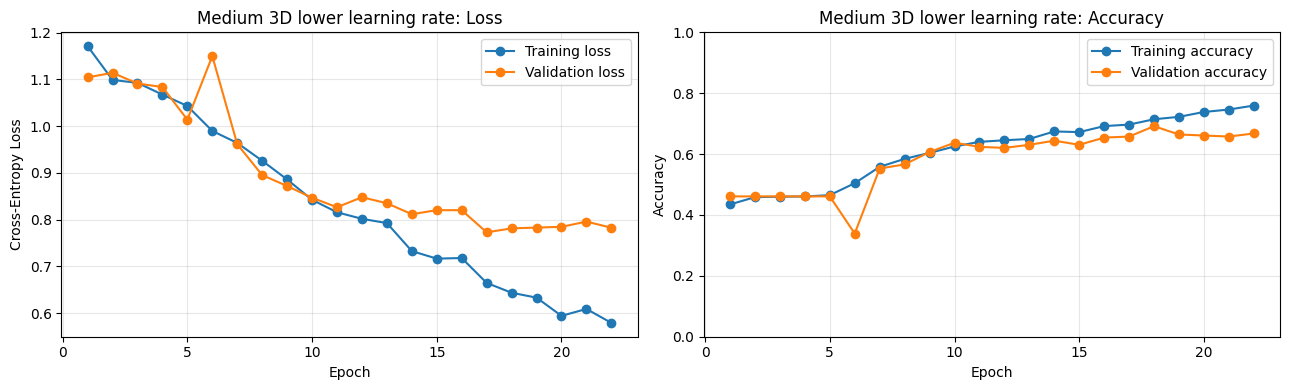


New best validation model: Medium 3D lower learning rate
Completed tuning trial 2/5
TRIAL: Stronger 3D regularization
Hyperparameters:
  conv_filters: (16, 32, 64)
  spatial_kernel_size: 3
  temporal_kernel_size: 3
  dense_units: 64
  dropout_rate: 0.45
  learning_rate: 0.0003
  l2_strength: 0.0005
  batch_size: 4

Model summary:


Model: "waymo_3d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ prior_rgb_clip (InputLayer)          │ (None, 16, 64, 160, 3)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_rescaling (Rescaling)          │ (None, 16, 64, 160, 3)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_1 (Conv3D)                    │ (None, 16, 64, 160, 16)     │           1,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_1 (ReLU)                        │ (None, 16, 64, 160, 16)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_1 (MaxPooling3D)          │ (None, 16, 32, 80, 16)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_1 (Dropout)             │ (None, 16, 32, 80, 16)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_2 (Conv3D)                    │ (None, 16, 32, 80, 32)      │          13,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_2 (ReLU)                        │ (None, 16, 32, 80, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_2 (MaxPooling3D)          │ (None, 8, 16, 40, 32)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_2 (Dropout)             │ (None, 8, 16, 40, 32)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_3 (Conv3D)                    │ (None, 8, 16, 40, 64)       │          55,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_3 (ReLU)                        │ (None, 8, 16, 40, 64)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_3 (MaxPooling3D)          │ (None, 4, 8, 20, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_3 (Dropout)             │ (None, 4, 8, 20, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ coarse_spatiotemporal_pool           │ (None, 2, 4, 5, 64)         │               0 │
│ (AveragePooling3D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2560)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_hidden (Dense)                 │ (None, 64)                  │         163,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_dropout (Dropout)              │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ class_probabilities (Dense)          │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 234,627 (916.51 KB)

 Trainable params: 234,627 (916.51 KB)

 Non-trainable params: 0 (0.00 B)


Parameter counts:
  total_parameters: 234,627
  trainable_parameters: 234,627
  non_trainable_parameters: 0
Epoch 1/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 61s 172ms/step - accuracy: 0.4259 - loss: 1.3140 - val_accuracy: 0.4610 - val_loss: 1.2166 - learning_rate: 3.0000e-04
Epoch 2/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 58s 170ms/step - accuracy: 0.4586 - loss: 1.2082 - val_accuracy: 0.4610 - val_loss: 1.2115 - learning_rate: 3.0000e-04
Epoch 3/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 59s 171ms/step - accuracy: 0.4528 - loss: 1.1988 - val_accuracy: 0.4610 - val_loss: 1.1928 - learning_rate: 3.0000e-04
Epoch 4/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 60s 174ms/step - accuracy: 0.4608 - loss: 1.1739 - val_accuracy: 0.4610 - val_loss: 1.1743 - learning_rate: 3.0000e-04
Epoch 5/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 59s 172ms/step - accuracy: 0.4600 - loss: 1.1639 - val_accuracy: 0.4610 - val_loss: 1.1629 - learning_rate: 3.0000e-04
Epoch 6/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 59s 172ms/step - accuracy: 0.4629 - loss: 1.1450 - val_a

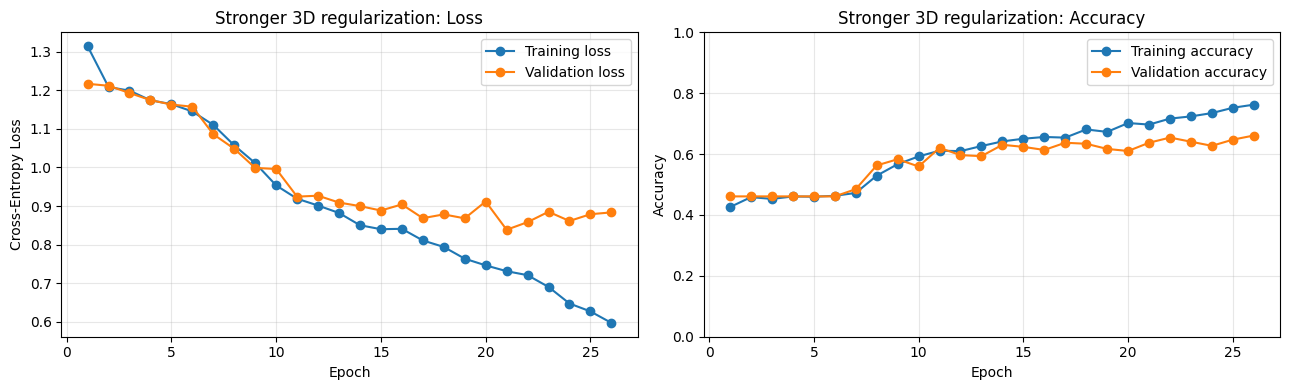

Completed tuning trial 3/5
TRIAL: Wider spatial kernel
Hyperparameters:
  conv_filters: (8, 16, 32)
  spatial_kernel_size: 5
  temporal_kernel_size: 3
  dense_units: 64
  dropout_rate: 0.3
  learning_rate: 0.0003
  l2_strength: 0.0001
  batch_size: 4

Model summary:


Model: "waymo_3d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ prior_rgb_clip (InputLayer)          │ (None, 16, 64, 160, 3)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_rescaling (Rescaling)          │ (None, 16, 64, 160, 3)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_1 (Conv3D)                    │ (None, 16, 64, 160, 8)      │           1,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_1 (ReLU)                        │ (None, 16, 64, 160, 8)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_1 (MaxPooling3D)          │ (None, 16, 32, 80, 8)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_1 (Dropout)             │ (None, 16, 32, 80, 8)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_2 (Conv3D)                    │ (None, 16, 32, 80, 16)      │           9,616 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_2 (ReLU)                        │ (None, 16, 32, 80, 16)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_2 (MaxPooling3D)          │ (None, 8, 16, 40, 16)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_2 (Dropout)             │ (None, 8, 16, 40, 16)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_3 (Conv3D)                    │ (None, 8, 16, 40, 32)       │          38,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_3 (ReLU)                        │ (None, 8, 16, 40, 32)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_3 (MaxPooling3D)          │ (None, 4, 8, 20, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_3 (Dropout)             │ (None, 4, 8, 20, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ coarse_spatiotemporal_pool           │ (None, 2, 4, 5, 32)         │               0 │
│ (AveragePooling3D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_hidden (Dense)                 │ (None, 64)                  │          81,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_dropout (Dropout)              │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ class_probabilities (Dense)          │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 132,035 (515.76 KB)

 Trainable params: 132,035 (515.76 KB)

 Non-trainable params: 0 (0.00 B)


Parameter counts:
  total_parameters: 132,035
  trainable_parameters: 132,035
  non_trainable_parameters: 0
Epoch 1/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 77s 220ms/step - accuracy: 0.4484 - loss: 1.1102 - val_accuracy: 0.4610 - val_loss: 1.0832 - learning_rate: 3.0000e-04
Epoch 2/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 75s 217ms/step - accuracy: 0.4629 - loss: 1.0831 - val_accuracy: 0.4610 - val_loss: 1.0955 - learning_rate: 3.0000e-04
Epoch 3/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 76s 222ms/step - accuracy: 0.4680 - loss: 1.0671 - val_accuracy: 0.4576 - val_loss: 1.0661 - learning_rate: 3.0000e-04
Epoch 4/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 76s 222ms/step - accuracy: 0.4840 - loss: 1.0376 - val_accuracy: 0.4847 - val_loss: 1.0422 - learning_rate: 3.0000e-04
Epoch 5/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 75s 218ms/step - accuracy: 0.5116 - loss: 1.0132 - val_accuracy: 0.5186 - val_loss: 1.0146 - learning_rate: 3.0000e-04
Epoch 6/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 75s 219ms/step - accuracy: 0.5211 - loss: 0.9883 - val_a

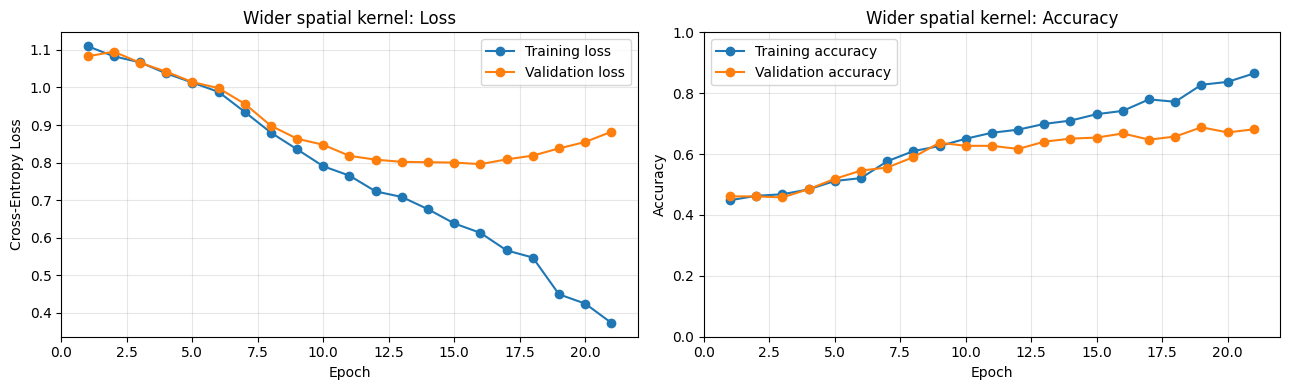


New best validation model: Wider spatial kernel
Completed tuning trial 4/5
TRIAL: Larger 3D dense head
Hyperparameters:
  conv_filters: (16, 32, 64)
  spatial_kernel_size: 3
  temporal_kernel_size: 3
  dense_units: 128
  dropout_rate: 0.4
  learning_rate: 0.0003
  l2_strength: 0.0001
  batch_size: 4

Model summary:


Model: "waymo_3d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ prior_rgb_clip (InputLayer)          │ (None, 16, 64, 160, 3)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_rescaling (Rescaling)          │ (None, 16, 64, 160, 3)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_1 (Conv3D)                    │ (None, 16, 64, 160, 16)     │           1,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_1 (ReLU)                        │ (None, 16, 64, 160, 16)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_1 (MaxPooling3D)          │ (None, 16, 32, 80, 16)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_1 (Dropout)             │ (None, 16, 32, 80, 16)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_2 (Conv3D)                    │ (None, 16, 32, 80, 32)      │          13,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_2 (ReLU)                        │ (None, 16, 32, 80, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_2 (MaxPooling3D)          │ (None, 8, 16, 40, 32)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_2 (Dropout)             │ (None, 8, 16, 40, 32)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_3 (Conv3D)                    │ (None, 8, 16, 40, 64)       │          55,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_3 (ReLU)                        │ (None, 8, 16, 40, 64)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_3 (MaxPooling3D)          │ (None, 4, 8, 20, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_3 (Dropout)             │ (None, 4, 8, 20, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ coarse_spatiotemporal_pool           │ (None, 2, 4, 5, 64)         │               0 │
│ (AveragePooling3D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2560)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_hidden (Dense)                 │ (None, 128)                 │         327,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_dropout (Dropout)              │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ class_probabilities (Dense)          │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 398,723 (1.52 MB)

 Trainable params: 398,723 (1.52 MB)

 Non-trainable params: 0 (0.00 B)


Parameter counts:
  total_parameters: 398,723
  trainable_parameters: 398,723
  non_trainable_parameters: 0
Epoch 1/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 62s 174ms/step - accuracy: 0.4368 - loss: 1.2177 - val_accuracy: 0.4610 - val_loss: 1.1138 - learning_rate: 3.0000e-04
Epoch 2/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 59s 172ms/step - accuracy: 0.4622 - loss: 1.1070 - val_accuracy: 0.4610 - val_loss: 1.1214 - learning_rate: 3.0000e-04
Epoch 3/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 59s 171ms/step - accuracy: 0.4629 - loss: 1.1004 - val_accuracy: 0.4610 - val_loss: 1.1097 - learning_rate: 3.0000e-04
Epoch 4/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 59s 172ms/step - accuracy: 0.4637 - loss: 1.0873 - val_accuracy: 0.4610 - val_loss: 1.0968 - learning_rate: 3.0000e-04
Epoch 5/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 59s 172ms/step - accuracy: 0.4746 - loss: 1.0718 - val_accuracy: 0.4847 - val_loss: 1.0438 - learning_rate: 3.0000e-04
Epoch 6/40
344/344 ━━━━━━━━━━━━━━━━━━━━ 59s 172ms/step - accuracy: 0.5087 - loss: 1.0212 - val_a

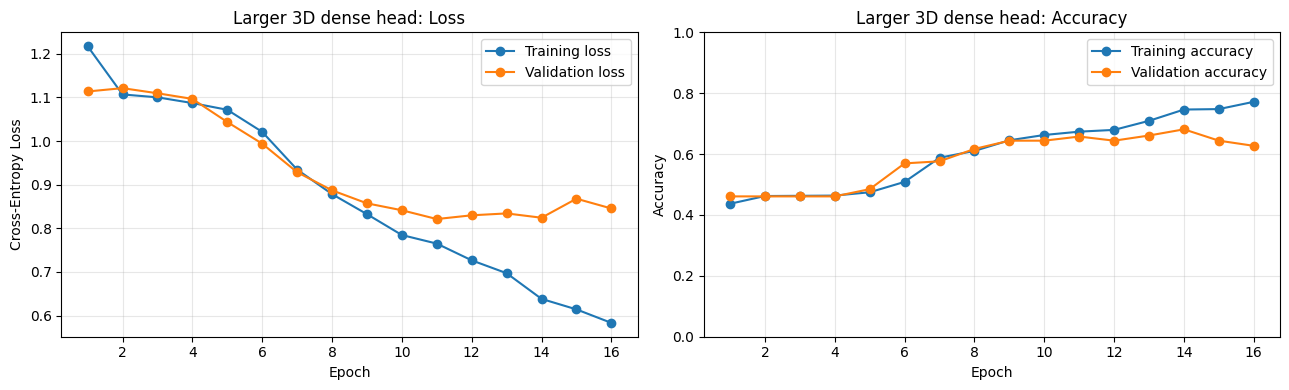

Completed tuning trial 5/5


In [15]:
for trial_number, trial_config in enumerate(
    TUNING_CONFIGS,
    start=1,
):
    trial_name = trial_config['name']
    model_config = {
        key: value
        for key, value in trial_config.items()
        if key != 'name'
    }

    trial_model, trial_history, trial_result = (
        train_and_validate_model(
            config=model_config,
            trial_name=trial_name,
            max_epochs=TUNING_EPOCHS,
            patience=EARLY_STOPPING_PATIENCE,
        )
    )

    tuning_records.append(trial_result)
    trial_score = selection_score(trial_result)

    if trial_score > best_score:
        best_score = trial_score
        best_config = model_config.copy()
        best_trial_name = trial_name
        best_weights = [
            weight.copy()
            for weight
            in trial_model.get_weights()
        ]
        best_history = {
            key: values.copy()
            for key, values
            in trial_history.history.items()
        }
        print(
            f'\nNew best validation model: '
            f'{best_trial_name}'
        )

    del trial_model
    del trial_history
    gc.collect()

    print(
        f'Completed tuning trial '
        f'{trial_number}/{len(TUNING_CONFIGS)}'
    )

In [16]:
tuning_results_df = pd.DataFrame(tuning_records)
tuning_results_df = tuning_results_df.sort_values(
    by=[
        'validation_f1_macro',
        'validation_accuracy',
        'validation_loss',
    ],
    ascending=[False, False, True],
).reset_index(drop=True)

tuning_results_display = tuning_results_df.copy()
four_decimal_columns = [
    'validation_loss',
    'validation_accuracy',
    'validation_precision_macro',
    'validation_recall_macro',
    'validation_sensitivity_macro',
    'validation_f1_macro',
]
tuning_results_display[four_decimal_columns] = (
    tuning_results_display[
        four_decimal_columns
    ].round(4)
)
tuning_results_display['training_seconds'] = (
    tuning_results_display[
        'training_seconds'
    ].round(1)
)

print(
    'Hyperparameter tuning results, ranked by '
    'validation macro F1:'
)
display(tuning_results_display)

print(f'\nSelected trial: {best_trial_name}')
print('Selected hyperparameters:')
for parameter_name, parameter_value in (
    best_config.items()
):
    print(
        f'  {parameter_name}: {parameter_value}'
    )

Hyperparameter tuning results, ranked by validation macro F1:


,trial,conv_filters,spatial_kernel_size,temporal_kernel_size,dense_units,dropout_rate,learning_rate,l2_strength,batch_size,epochs_run,best_epoch,total_parameters,validation_loss,validation_accuracy,validation_precision_macro,validation_recall_macro,validation_sensitivity_macro,validation_f1_macro,training_seconds
0,Wider spatial kernel,"(8, 16, 32)",5,3,64,0.30,0.0003,0.0001,4,21,16,132035,0.7957,0.6678,0.6391,0.6256,0.6256,0.6291,1606.3
1,Medium 3D lower learning rate,"(16, 32, 64)",3,3,64,0.30,0.0003,0.0001,4,22,17,234627,0.7728,0.6576,0.6342,0.5967,0.5967,0.6003,1318.2
2,Stronger 3D regularization,"(16, 32, 64)",3,3,64,0.45,0.0003,0.0005,4,26,21,234627,0.8387,0.6373,0.5927,0.5835,0.5835,0.5849,1537.0
3,Larger 3D dense head,"(16, 32, 64)",3,3,128,0.40,0.0003,0.0001,4,16,11,398723,0.8213,0.6576,0.6792,0.5842,0.5842,0.5696,952.4
4,Medium 3D capacity,"(16, 32, 64)",3,3,64,0.30,0.0010,0.0001,4,19,14,234627,0.8502,0.6475,0.6482,0.5675,0.5675,0.5577,1145.0
5,Initial 3D CNN,"(8, 16, 32)",3,3,64,0.25,0.0010,0.0001,4,16,11,100163,0.8393,0.6475,0.6491,0.5621,0.5621,0.5558,439.8



Selected trial: Wider spatial kernel
Selected hyperparameters:
  conv_filters: (8, 16, 32)
  spatial_kernel_size: 5
  temporal_kernel_size: 3
  dense_units: 64
  dropout_rate: 0.3
  learning_rate: 0.0003
  l2_strength: 0.0001
  batch_size: 4


# Step 12: Rebuild the selected 3D model and examine validation performance

The selected early-stopped weights are loaded into a fresh copy of the
winning architecture. The validation split is still the only split used
for selection.

Selected model: Wider spatial kernel


Model: "waymo_3d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ prior_rgb_clip (InputLayer)          │ (None, 16, 64, 160, 3)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_rescaling (Rescaling)          │ (None, 16, 64, 160, 3)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_1 (Conv3D)                    │ (None, 16, 64, 160, 8)      │           1,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_1 (ReLU)                        │ (None, 16, 64, 160, 8)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_1 (MaxPooling3D)          │ (None, 16, 32, 80, 8)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_1 (Dropout)             │ (None, 16, 32, 80, 8)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_2 (Conv3D)                    │ (None, 16, 32, 80, 16)      │           9,616 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_2 (ReLU)                        │ (None, 16, 32, 80, 16)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_2 (MaxPooling3D)          │ (None, 8, 16, 40, 16)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_2 (Dropout)             │ (None, 8, 16, 40, 16)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_3 (Conv3D)                    │ (None, 8, 16, 40, 32)       │          38,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu_3 (ReLU)                        │ (None, 8, 16, 40, 32)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool3d_3 (MaxPooling3D)          │ (None, 4, 8, 20, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dropout_3 (Dropout)             │ (None, 4, 8, 20, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ coarse_spatiotemporal_pool           │ (None, 2, 4, 5, 32)         │               0 │
│ (AveragePooling3D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_hidden (Dense)                 │ (None, 64)                  │          81,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_dropout (Dropout)              │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ class_probabilities (Dense)          │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 132,035 (515.76 KB)

 Trainable params: 132,035 (515.76 KB)

 Non-trainable params: 0 (0.00 B)


Selected model parameter counts:
  total_parameters: 132,035
  trainable_parameters: 132,035
  non_trainable_parameters: 0


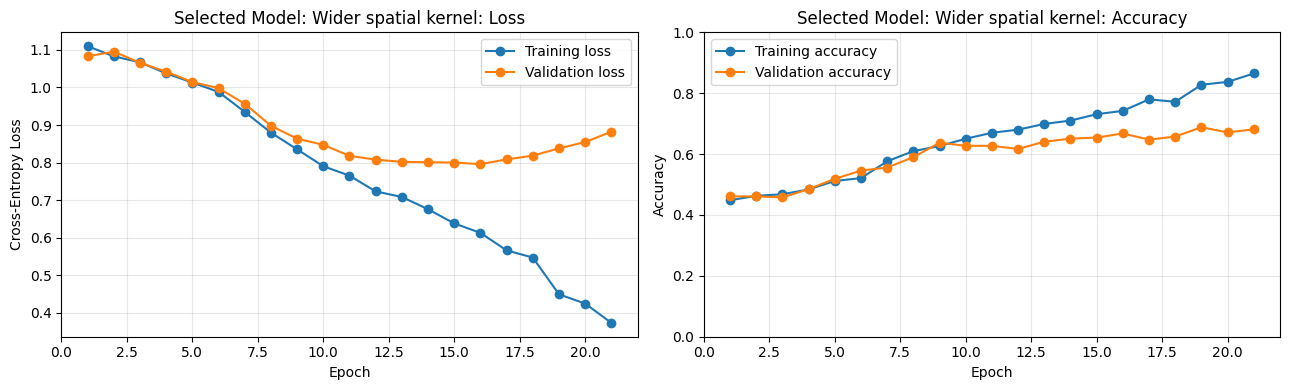

In [17]:
tf.keras.backend.clear_session()
best_model = build_model_from_config(best_config)
best_model.set_weights(best_weights)

print(f'Selected model: {best_trial_name}')
best_model.summary()

best_parameter_counts = count_model_parameters(
    best_model
)
print('\nSelected model parameter counts:')
for parameter_name, parameter_value in (
    best_parameter_counts.items()
):
    print(
        f'  {parameter_name}: '
        f'{parameter_value:,}'
    )

plot_training_history(
    best_history,
    f'Selected Model: {best_trial_name}',
)

74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
Selected 3D CNN validation metrics:


,accuracy,precision_macro,recall_macro,sensitivity_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,,
Selected 3D CNN Validation: Wider spatial kernel,0.6678,0.6391,0.6256,0.6256,0.6291,0.6583,0.6678,0.6596


Selected 3D CNN validation classification report:


,precision,recall,f1-score,support
straight,0.7325,0.8456,0.7850,136.0000
right-turn,0.6133,0.5169,0.5610,89.0000
left-turn,0.5714,0.5143,0.5414,70.0000
accuracy,0.6678,0.6678,0.6678,0.6678
macro avg,0.6391,0.6256,0.6291,295.0000
weighted avg,0.6583,0.6678,0.6596,295.0000


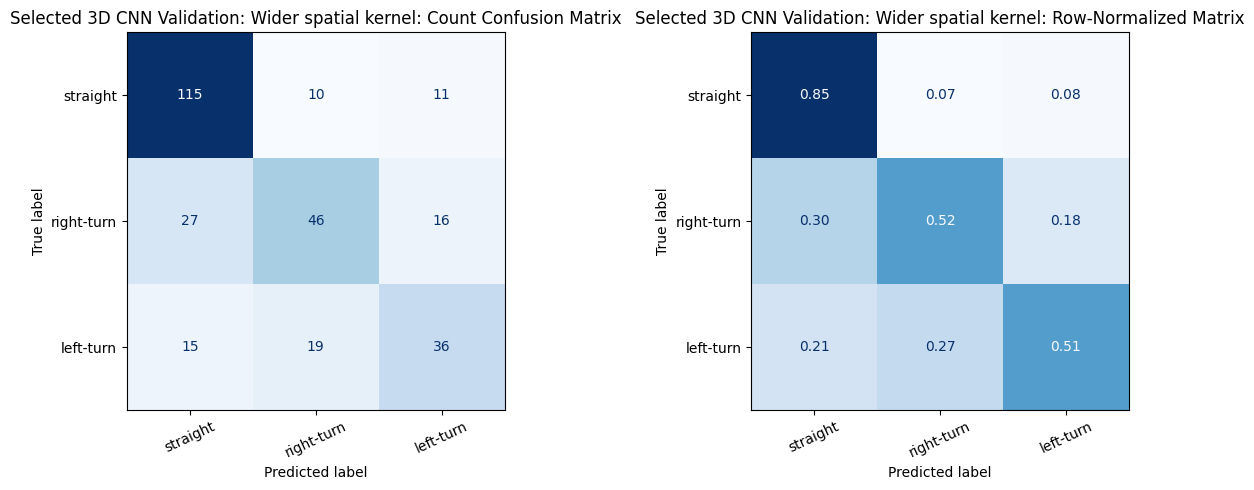

12421

In [18]:
validation_sequence = make_clip_sequence(
    split_name='val',
    batch_size=best_config['batch_size'],
    shuffle=False,
    seed=SEED,
)

validation_probabilities = best_model.predict(
    validation_sequence,
    verbose=1,
)
validation_predictions = np.argmax(
    validation_probabilities,
    axis=1,
)

selected_validation_metrics = calculate_metrics(
    y_val,
    validation_predictions,
    f'Selected 3D CNN Validation: '
    f'{best_trial_name}',
)

print('Selected 3D CNN validation metrics:')
display(
    pd.DataFrame(
        [selected_validation_metrics]
    )
    .set_index('model')
    .round(4)
)

print(
    'Selected 3D CNN validation '
    'classification report:'
)
display(
    classification_report_df(
        y_val,
        validation_predictions,
    ).round(4)
)

plot_confusion_matrices(
    y_val,
    validation_predictions,
    f'Selected 3D CNN Validation: '
    f'{best_trial_name}',
)

del validation_sequence
gc.collect()

# Step 13: Evaluate the two baseline models on the test split

The chance baseline samples the three classes uniformly. The
majority-class baseline always predicts the most common training label.

Theoretical chance accuracy: 0.3333
Majority class from training data: straight (634 training clips)

Chance Baseline


,accuracy,precision_macro,recall_macro,sensitivity_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,,
Chance Baseline,0.322,0.3269,0.3232,0.3232,0.3167,0.3558,0.322,0.3293


,precision,recall,f1-score,support
straight,0.4725,0.3162,0.3789,136.000
right-turn,0.2710,0.3295,0.2974,88.000
left-turn,0.2371,0.3239,0.2738,71.000
accuracy,0.3220,0.3220,0.3220,0.322
macro avg,0.3269,0.3232,0.3167,295.000
weighted avg,0.3558,0.3220,0.3293,295.000


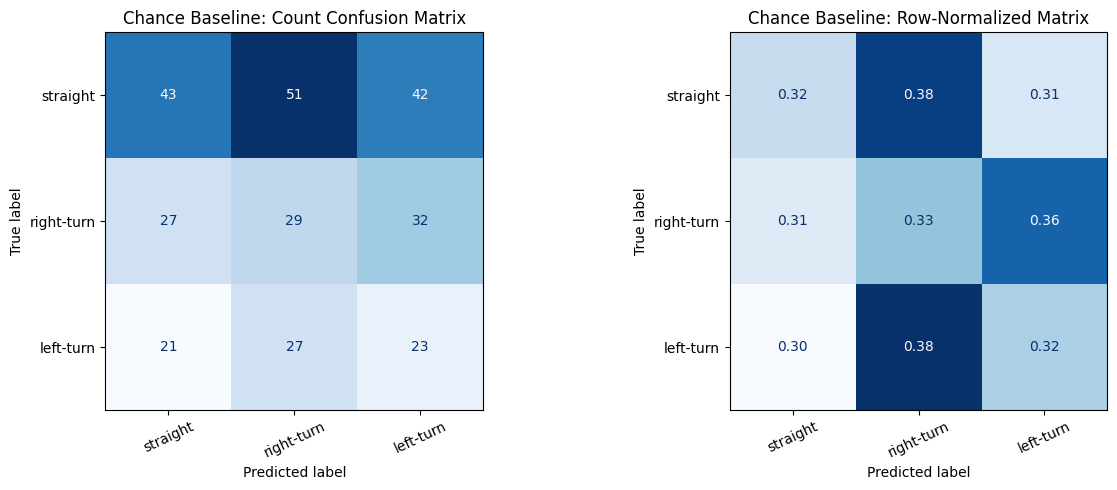


Majority-Class Baseline


,accuracy,precision_macro,recall_macro,sensitivity_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,,
Majority-Class Baseline,0.461,0.1537,0.3333,0.3333,0.2104,0.2125,0.461,0.2909


,precision,recall,f1-score,support
straight,0.4610,1.0000,0.6311,136.000
right-turn,0.0000,0.0000,0.0000,88.000
left-turn,0.0000,0.0000,0.0000,71.000
accuracy,0.4610,0.4610,0.4610,0.461
macro avg,0.1537,0.3333,0.2104,295.000
weighted avg,0.2125,0.4610,0.2909,295.000


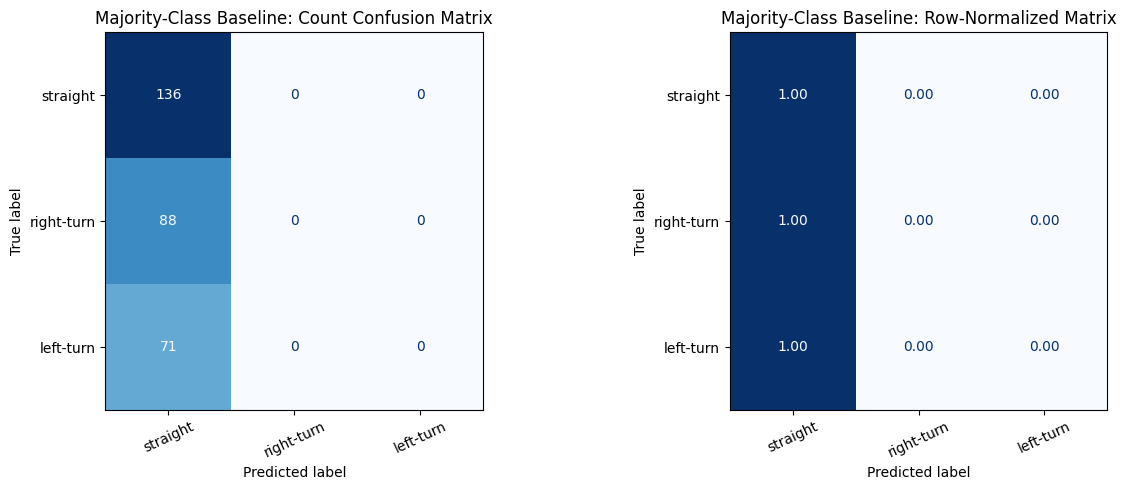

In [19]:
chance_rng = np.random.default_rng(SEED)
chance_predictions = chance_rng.integers(
    low=0,
    high=NUM_CLASSES,
    size=len(y_test),
)

training_class_counts = np.bincount(
    y_train,
    minlength=NUM_CLASSES,
)
majority_class_id = int(
    np.argmax(training_class_counts)
)
majority_predictions = np.full(
    shape=len(y_test),
    fill_value=majority_class_id,
    dtype=np.int32,
)

print(
    f'Theoretical chance accuracy: '
    f'{1 / NUM_CLASSES:.4f}'
)
print(
    f'Majority class from training data: '
    f'{ID_TO_CLASS[majority_class_id]} '
    f'({training_class_counts[majority_class_id]:,} '
    'training clips)'
)

baseline_predictions = {
    'Chance Baseline': chance_predictions,
    'Majority-Class Baseline': (
        majority_predictions
    ),
}
baseline_metric_rows = []

for baseline_name, predictions in (
    baseline_predictions.items()
):
    print('\n' + '=' * 100)
    print(baseline_name)

    baseline_metrics = calculate_metrics(
        y_test,
        predictions,
        baseline_name,
    )
    baseline_metric_rows.append(baseline_metrics)

    display(
        pd.DataFrame([baseline_metrics])
        .set_index('model')
        .round(4)
    )
    display(
        classification_report_df(
            y_test,
            predictions,
        ).round(4)
    )
    plot_confusion_matrices(
        y_test,
        predictions,
        baseline_name,
    )

# Step 14: Report final 3D CNN metrics on the test split

Run this section only after the temporal architecture and
hyperparameters have been finalized from validation results.

74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6237 - loss: 0.8108
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
TensorFlow test evaluation:
  accuracy: 0.6237
  loss: 0.8108

3D CNN test metrics:


,accuracy,precision_macro,recall_macro,sensitivity_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,,
Selected 3D CNN: Wider spatial kernel,0.6237,0.5615,0.5667,0.5667,0.5633,0.6126,0.6237,0.6175


3D CNN test classification report:


,precision,recall,f1-score,support
straight,0.7929,0.8162,0.8043,136.0000
right-turn,0.5638,0.6023,0.5824,88.0000
left-turn,0.3279,0.2817,0.3030,71.0000
accuracy,0.6237,0.6237,0.6237,0.6237
macro avg,0.5615,0.5667,0.5633,295.0000
weighted avg,0.6126,0.6237,0.6175,295.0000


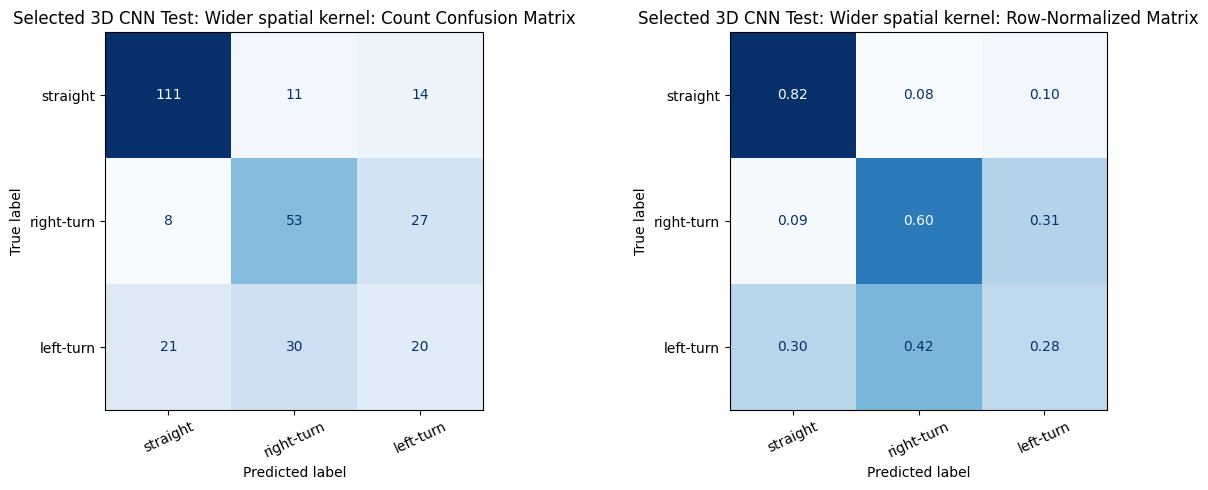

4875

In [20]:
test_sequence = make_clip_sequence(
    split_name='test',
    batch_size=best_config['batch_size'],
    shuffle=False,
    seed=SEED,
)

test_evaluation = best_model.evaluate(
    test_sequence,
    verbose=1,
    return_dict=True,
)

test_probabilities = best_model.predict(
    test_sequence,
    verbose=1,
)
test_predictions = np.argmax(
    test_probabilities,
    axis=1,
)

cnn_test_metrics = calculate_metrics(
    y_test,
    test_predictions,
    f'Selected 3D CNN: {best_trial_name}',
)

print('TensorFlow test evaluation:')
for metric_name, metric_value in (
    test_evaluation.items()
):
    print(
        f'  {metric_name}: {metric_value:.4f}'
    )

print('\n3D CNN test metrics:')
display(
    pd.DataFrame([cnn_test_metrics])
    .set_index('model')
    .round(4)
)

print('3D CNN test classification report:')
display(
    classification_report_df(
        y_test,
        test_predictions,
    ).round(4)
)

plot_confusion_matrices(
    y_test,
    test_predictions,
    f'Selected 3D CNN Test: '
    f'{best_trial_name}',
)

del test_sequence
gc.collect()

# Step 15: Compare the selected 3D CNN with both baselines

Final test-set model comparison:


,accuracy,precision_macro,recall_macro,sensitivity_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,,
Chance Baseline,0.3220,0.3269,0.3232,0.3232,0.3167,0.3558,0.3220,0.3293
Majority-Class Baseline,0.4610,0.1537,0.3333,0.3333,0.2104,0.2125,0.4610,0.2909
Selected 3D CNN: Wider spatial kernel,0.6237,0.5615,0.5667,0.5667,0.5633,0.6126,0.6237,0.6175


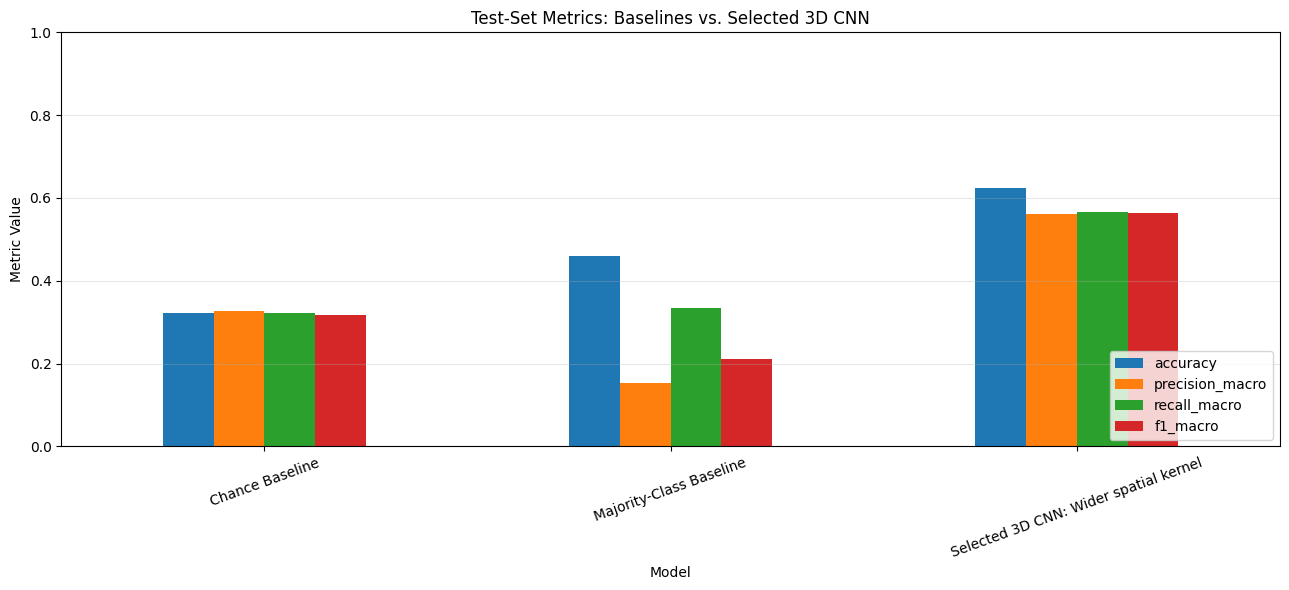

In [21]:
comparison_df = pd.DataFrame(
    baseline_metric_rows + [cnn_test_metrics]
).set_index('model')

print('Final test-set model comparison:')
display(comparison_df.round(4))

comparison_columns = [
    'accuracy',
    'precision_macro',
    'recall_macro',
    'f1_macro',
]

ax = comparison_df[
    comparison_columns
].plot(
    kind='bar',
    figsize=(13, 6),
    ylim=(0, 1),
)

ax.set_title(
    'Test-Set Metrics: Baselines vs. '
    'Selected 3D CNN'
)
ax.set_xlabel('Model')
ax.set_ylabel('Metric Value')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Output Penultimate feature vector to be used in downstream Classification

In [22]:
# Save learned 3D CNN features and corresponding labels.
FEATURES_DIR = (
    PROJECT_ROOT
    / 'data'
    / 'processed'
    / 'waymo_e2e'
    / 'features'
)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

CNN_FEATURE_PATH = FEATURES_DIR / 'CNN_3D.npy'
CNN_LABEL_PATH = FEATURES_DIR / 'labels_CNN_3D.npy'

# Use the final hidden layer as the learned 3D CNN feature vector.
cnn_feature_extractor = tf.keras.Model(
    inputs=best_model.inputs,
    outputs=best_model.get_layer('dense_hidden').output,
    name='cnn_3d_feature_extractor',
)

cnn_feature_splits = []

for split_name in SPLIT_NAMES:
    print(f'Extracting {split_name} 3D CNN features...')

    # Keep shuffle=False so rows remain in their original split order.
    feature_sequence = make_clip_sequence(
        split_name=split_name,
        batch_size=best_config['batch_size'],
        shuffle=False,
        seed=SEED,
    )

    split_features = cnn_feature_extractor.predict(
        feature_sequence,
        verbose=1,
    )

    # Confirm that every input clip produced one feature vector.
    if split_features.shape[0] != len(
        split_dfs[split_name]
    ):
        raise ValueError(
            f'{split_name} feature row mismatch: '
            f'{split_features.shape[0]} features and '
            f'{len(split_dfs[split_name])} dataframe rows.'
        )

    cnn_feature_splits.append(
        split_features.astype(np.float32)
    )

    print(
        f'  {split_name}: '
        f'{split_features.shape}'
    )

    del feature_sequence
    gc.collect()

# Preserve training, validation, and test ordering.
cnn_features = np.concatenate(
    cnn_feature_splits,
    axis=0,
)

# Save readable class names rather than encoded integers.
cnn_labels = np.concatenate([
    split_label_dfs[split_name]['class_label']
    .astype(str)
    .to_numpy()
    for split_name in SPLIT_NAMES
]).astype('<U20')

if cnn_features.shape[0] != cnn_labels.shape[0]:
    raise ValueError(
        f'Feature/label row mismatch: '
        f'{cnn_features.shape[0]} features and '
        f'{cnn_labels.shape[0]} labels.'
    )

if not np.isfinite(cnn_features).all():
    raise ValueError(
        'CNN features contain NaN or infinite values.'
    )

np.save(CNN_FEATURE_PATH, cnn_features)
np.save(CNN_LABEL_PATH, cnn_labels)

print('\nSaved 3D CNN feature files:')
print(f'  {CNN_FEATURE_PATH}')
print(f'  {CNN_LABEL_PATH}')
print(f'\nCNN feature shape: {cnn_features.shape}')
print(f'CNN label shape: {cnn_labels.shape}')
print(f'CNN feature dtype: {cnn_features.dtype}')

# Print the row boundaries for each split.
row_start = 0

for split_name in SPLIT_NAMES:
    row_end = row_start + len(
        split_dfs[split_name]
    )

    print(
        f'{split_name}: rows '
        f'{row_start:,} through {row_end - 1:,}'
    )

    row_start = row_end

print('\nLabel distribution:')
print(
    pd.Series(cnn_labels)
    .value_counts()
    .reindex(CLASS_NAMES)
)

Extracting train 3D CNN features...
344/344 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step
  train: (1376, 64)
Extracting val 3D CNN features...
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
  val: (295, 64)
Extracting test 3D CNN features...
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
  test: (295, 64)

Saved 3D CNN feature files:
  C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\features\CNN_3D.npy
  C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\features\labels_CNN_3D.npy

CNN feature shape: (1966, 64)
CNN label shape: (1966,)
CNN feature dtype: float32
train: rows 0 through 1,375
val: rows 1,376 through 1,670
test: rows 1,671 through 1,965

Label distribution:
straight      906
right-turn    589
left-turn     471
Name: count, dtype: int64
